# 01 - Data Pipeline

Notebook da Pessoa 1 para a Fase 1 do Projeto 2 de Introducao a Inteligencia Artificial.

Objetivo: ler ortofotos GeoTIFF da Asa Norte baixadas do Geoportal IDE-DF e fatiar cada imagem em tiles GeoTIFF de `640x640` pixels usando `rasterio` e `rasterio.windows.Window`, preservando os metadados geograficos de cada recorte.

Este notebook nao executa DeepForest, YOLO, treinamento, HDF5, Roboflow, Kaggle ou conversao para JPEG.

## Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import pandas as pd
from rasterio.io import MemoryFile
from rasterio.transform import from_bounds
from rasterio.windows import Window

## Configuracao de caminhos

Baixe as ortofotos GeoTIFF da Asa Norte no Geoportal IDE-DF conforme indicado no PDF e coloque os arquivos em `data/raw/`. Cada ortofoto ou setor processado gera sua propria pasta em `data/tiles/`.

Os caminhos abaixo sao relativos ao diretorio raiz do projeto.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
TILES_DIR = PROJECT_ROOT / "data" / "tiles"

RAW_DIR.mkdir(parents=True, exist_ok=True)
TILES_DIR.mkdir(parents=True, exist_ok=True)

# Caminhos padrao para processamento manual de um unico arquivo, se necessario.
INPUT_GEOTIFF = RAW_DIR / "asa_norte_setor_01.tif"
OUTPUT_TILE_DIR = TILES_DIR / INPUT_GEOTIFF.stem

print(f"Pasta de entrada: {RAW_DIR}")
print(f"Pasta de saida dos tiles: {TILES_DIR}")

Pasta de entrada: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/raw
Pasta de saida dos tiles: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/tiles


## Download de recorte via WMS

Esta secao opcional tenta baixar varios recortes menores da Asa Norte a partir do servico WMS oficial indicado pela equipe. Usar setores evita uma imagem gigante unica, reduzindo o risco de falha no WMS e mantendo os arquivos organizados para as proximas etapas.

`Imagem 2021 GeoEye/WorldView I e II`

Servico WMS: `https://www.geoservicos.ide.df.gov.br/arcgis/services/Imagens/2021_50CM/ImageServer/WMSServer`

Observacao: WMS e voltado para mapas renderizados. Mesmo quando o formato `image/tiff` e aceito, a resposta pode nao vir como GeoTIFF completo com metadados espaciais embutidos. Por isso, o codigo abaixo usa a bbox solicitada para gravar um GeoTIFF local com `crs` e `transform` definidos via `rasterio`. Se o WMS falhar ou retornar XML de erro, baixe manualmente um GeoTIFF pelo Geoportal IDE-DF e salve em `data/raw/asa_norte_setor_01.tif`.

A celula de download esta configurada para nao sobrescrever um arquivo existente, exceto se o arquivo existente tiver dimensoes diferentes das esperadas para os setores WMS.

In [3]:
WMS_URL = "https://www.geoservicos.ide.df.gov.br/arcgis/services/Imagens/2021_50CM/ImageServer/WMSServer"
WMS_LAYER = "0"

# Bboxes aproximadas na Asa Norte em CRS:84: oeste, sul, leste, norte.
# Cada setor usa um recorte moderado para evitar requisicoes WMS grandes demais.
ASA_NORTE_WMS_SECTORS = [
    {"name": "asa_norte_setor_01", "bbox": (-47.890, -15.780, -47.880, -15.770)},
    {"name": "asa_norte_setor_02", "bbox": (-47.880, -15.780, -47.870, -15.770)},
    {"name": "asa_norte_setor_03", "bbox": (-47.890, -15.770, -47.880, -15.760)},
    {"name": "asa_norte_setor_04", "bbox": (-47.880, -15.770, -47.870, -15.760)},
    {"name": "asa_norte_setor_05", "bbox": (-47.890, -15.760, -47.880, -15.750)},
    {"name": "asa_norte_setor_06", "bbox": (-47.880, -15.760, -47.870, -15.750)},
]

# 2560x2560 gera 16 tiles 640x640 por setor.
WMS_OUTPUT_WIDTH = 2560
WMS_OUTPUT_HEIGHT = 2560


def download_wms_geotiff(output_path, bbox, width=640, height=640, overwrite=False):
    """
    Baixa um recorte WMS em image/tiff e salva como GeoTIFF georreferenciado.

    Como WMS retorna uma imagem renderizada, o georreferenciamento e reconstruido
    a partir da bbox solicitada e do CRS usado na requisicao.
    """
    import requests

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not overwrite:
        with rasterio.open(output_path) as existing:
            same_shape = existing.width == width and existing.height == height
            expected_bounds = tuple(round(value, 6) for value in bbox)
            current_bounds = (
                round(existing.bounds.left, 6),
                round(existing.bounds.bottom, 6),
                round(existing.bounds.right, 6),
                round(existing.bounds.top, 6),
            )
            same_bounds = current_bounds == expected_bounds

        if same_shape and same_bounds:
            print(f"Arquivo ja existe e nao sera sobrescrito: {output_path}")
            return output_path

        print(f"Arquivo existente difere da configuracao atual e sera recriado: {output_path}")

    params = {
        "service": "WMS",
        "version": "1.3.0",
        "request": "GetMap",
        "layers": WMS_LAYER,
        "styles": "",
        "crs": "CRS:84",
        "bbox": ",".join(str(value) for value in bbox),
        "width": width,
        "height": height,
        "format": "image/tiff",
        "transparent": "false",
    }

    response = requests.get(WMS_URL, params=params, timeout=60)
    response.raise_for_status()

    content_start = response.content[:100].lstrip().lower()
    content_type = response.headers.get("content-type", "").lower()
    if content_start.startswith(b"<?xml") or "xml" in content_type:
        message = response.text[:500]
        raise RuntimeError(f"O WMS retornou XML em vez de TIFF: {message}")

    west, south, east, north = bbox
    transform = from_bounds(west, south, east, north, width, height)

    with MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            profile = src.profile.copy()
            profile.update(
                {
                    "driver": "GTiff",
                    "crs": "EPSG:4326",
                    "transform": transform,
                    "width": width,
                    "height": height,
                }
            )

            with rasterio.open(output_path, "w", **profile) as dst:
                dst.write(src.read())

    print(f"Recorte WMS salvo em: {output_path}")
    return output_path


def download_wms_sectors(sectors, raw_dir, width=2560, height=2560, overwrite=False):
    """Baixa todos os setores WMS configurados e retorna os caminhos GeoTIFF."""
    raw_dir = Path(raw_dir)
    geotiff_paths = []

    for sector in sectors:
        output_path = raw_dir / f"{sector['name']}.tif"
        print(f"\nProcessando download do setor: {sector['name']}")
        geotiff_paths.append(
            download_wms_geotiff(
                output_path,
                sector["bbox"],
                width=width,
                height=height,
                overwrite=overwrite,
            )
        )

    print(f"\nTotal de GeoTIFFs disponiveis: {len(geotiff_paths)}")
    return geotiff_paths

In [4]:
# Execute esta celula para tentar criar os GeoTIFFs de entrada via WMS.
# Por seguranca, ela nao sobrescreve GeoTIFFs ja existentes com as dimensoes esperadas.
RUN_WMS_DOWNLOAD = True

if RUN_WMS_DOWNLOAD:
    try:
        input_geotiffs = download_wms_sectors(
            ASA_NORTE_WMS_SECTORS,
            RAW_DIR,
            width=WMS_OUTPUT_WIDTH,
            height=WMS_OUTPUT_HEIGHT,
            overwrite=False,
        )
    except Exception as exc:
        print(f"Nao foi possivel baixar o recorte via WMS: {exc}")
        input_geotiffs = sorted(RAW_DIR.glob("asa_norte_setor_*.tif"))
        print("Use GeoTIFFs baixados manualmente em data/raw/asa_norte_setor_*.tif.")
else:
    input_geotiffs = sorted(RAW_DIR.glob("asa_norte_setor_*.tif"))

print(f"GeoTIFFs de entrada encontrados: {len(input_geotiffs)}")


Processando download do setor: asa_norte_setor_01
Recorte WMS salvo em: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/raw/asa_norte_setor_01.tif

Processando download do setor: asa_norte_setor_02
Recorte WMS salvo em: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/raw/asa_norte_setor_02.tif

Processando download do setor: asa_norte_setor_03
Recorte WMS salvo em: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/raw/asa_norte_setor_03.tif

Processando download do setor: asa_norte_setor_04
Recorte WMS salvo em: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/raw/asa_norte_setor_04.tif

Processando download do setor: asa_norte_setor_05
Recorte WMS salvo em: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/raw/asa_norte_setor_05.tif

Processando download do setor: asa_norte_setor_06
Recorte WMS salvo em: /home/kohara/IIA/IIA-Arvores-AsaNorte/data/raw/asa_norte_setor_06.tif

Total de GeoTIFFs disponiveis: 6
GeoTIFFs de entrada encontrados: 6


## Implementacao

A funcao `slice_geotiff` percorre a imagem em janelas fixas de `640x640`. Tiles incompletos nas bordas sao ignorados para manter dimensoes uniformes. A pasta de saida deve ser especifica para a ortofoto processada.

In [5]:
def slice_geotiff(input_path, output_dir, tile_size=640):
    """
    Divide um GeoTIFF grande em tiles menores, preservando metadados geograficos.

    Parametros
    ----------
    input_path : str | pathlib.Path
        Caminho do arquivo GeoTIFF de entrada.
    output_dir : str | pathlib.Path
        Pasta onde os tiles GeoTIFF serao salvos.
    tile_size : int
        Tamanho do tile quadrado em pixels. O padrao do projeto e 640.

    Retorno
    -------
    list[pathlib.Path]
        Lista com os caminhos dos tiles gerados.
    """
    input_path = Path(input_path)
    output_dir = Path(output_dir)

    if tile_size <= 0:
        raise ValueError("tile_size deve ser um inteiro positivo.")

    if not input_path.exists():
        raise FileNotFoundError(f"Arquivo GeoTIFF nao encontrado: {input_path}")

    output_dir.mkdir(parents=True, exist_ok=True)
    generated_tiles = []

    with rasterio.open(input_path) as src:
        meta = src.meta.copy()
        img_width = src.width
        img_height = src.height

        print(f"Dimensoes da imagem original: {img_width}x{img_height}")
        print(f"CRS: {src.crs}")

        for row_off in range(0, img_height - tile_size + 1, tile_size):
            for col_off in range(0, img_width - tile_size + 1, tile_size):
                window = Window(
                    col_off=col_off,
                    row_off=row_off,
                    width=tile_size,
                    height=tile_size,
                )
                tile_transform = rasterio.windows.transform(window, src.transform)

                tile_meta = meta.copy()
                tile_meta.update(
                    {
                        "height": tile_size,
                        "width": tile_size,
                        "transform": tile_transform,
                    }
                )

                tile_name = f"{input_path.stem}_tile_{row_off}_{col_off}.tif"
                output_path = output_dir / tile_name

                with rasterio.open(output_path, "w", **tile_meta) as dst:
                    dst.write(src.read(window=window))

                generated_tiles.append(output_path)

    print(f"Total de tiles gerados: {len(generated_tiles)}")
    return generated_tiles

## Funcoes auxiliares

In [6]:
def count_tiles(tile_dir, pattern="*.tif"):
    """Conta quantos tiles existem na pasta informada."""
    tile_dir = Path(tile_dir)
    return len(sorted(tile_dir.glob(pattern)))


def validate_tile_dimensions(tile_dir, expected_size=640, pattern="*.tif"):
    """Valida se todos os tiles possuem exatamente expected_size x expected_size pixels."""
    tile_dir = Path(tile_dir)
    tile_paths = sorted(tile_dir.glob(pattern))
    invalid_tiles = []

    if not tile_paths:
        print(f"Nenhum tile encontrado em {tile_dir}.")
        return False

    for tile_path in tile_paths:
        with rasterio.open(tile_path) as src:
            if src.width != expected_size or src.height != expected_size:
                invalid_tiles.append((tile_path, src.width, src.height))

    if invalid_tiles:
        print("Tiles com dimensoes invalidas:")
        for tile_path, width, height in invalid_tiles:
            print(f"- {tile_path.name}: {width}x{height}")
        return False

    print(f"Todos os tiles possuem {expected_size}x{expected_size} pixels.")
    return True


def validate_tile_georeferencing(tile_dir, pattern="*.tif"):
    """Valida se todos os tiles possuem CRS e transform georreferenciado."""
    tile_dir = Path(tile_dir)
    tile_paths = sorted(tile_dir.glob(pattern))
    invalid_tiles = []

    if not tile_paths:
        print(f"Nenhum tile encontrado em {tile_dir}.")
        return False

    for tile_path in tile_paths:
        with rasterio.open(tile_path) as src:
            if src.crs is None or src.transform.is_identity:
                invalid_tiles.append(tile_path)

    if invalid_tiles:
        print("Tiles sem CRS ou transform georreferenciado:")
        for tile_path in invalid_tiles:
            print(f"- {tile_path.name}")
        return False

    print("Todos os tiles possuem CRS e transform georreferenciado.")
    return True


def _prepare_image_for_display(array):
    """Converte array lido pelo rasterio para exibicao com matplotlib."""
    if array.shape[0] == 1:
        return array[0], "gray"

    image = array[:3].transpose(1, 2, 0)

    if image.dtype != np.uint8:
        p2, p98 = np.percentile(image, (2, 98))
        image = np.clip((image - p2) / (p98 - p2 + 1e-9), 0, 1)

    return image, None


def show_sample_tiles(tile_dir, n=4, pattern="*.tif"):
    """Mostra alguns tiles para inspecao visual rapida."""
    tile_dir = Path(tile_dir)
    tile_paths = sorted(tile_dir.glob(pattern))[:n]

    if not tile_paths:
        print(f"Nenhum tile encontrado em {tile_dir}.")
        return

    cols = min(n, len(tile_paths))
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 4))
    axes = np.atleast_1d(axes)

    for ax, tile_path in zip(axes, tile_paths):
        with rasterio.open(tile_path) as src:
            image, cmap = _prepare_image_for_display(src.read())

        ax.imshow(image, cmap=cmap)
        ax.set_title(tile_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Execucao

Depois de baixar ou gerar os GeoTIFFs da Asa Norte, execute a celula abaixo. Cada arquivo `data/raw/asa_norte_setor_XX.tif` gera tiles em `data/tiles/asa_norte_setor_XX/`.

In [7]:
generated_tiles_by_sector = {}

for geotiff_path in input_geotiffs:
    output_tile_dir = TILES_DIR / geotiff_path.stem
    print(f"\nFatiando {geotiff_path.name} -> {output_tile_dir}")
    generated_tiles_by_sector[geotiff_path.stem] = slice_geotiff(
        geotiff_path,
        output_tile_dir,
        tile_size=640,
    )

total_generated_tiles = sum(len(paths) for paths in generated_tiles_by_sector.values())
print(f"\nTotal de GeoTIFFs processados: {len(generated_tiles_by_sector)}")
print(f"Total de tiles gerados: {total_generated_tiles}")


Fatiando asa_norte_setor_01.tif -> /home/kohara/IIA/IIA-Arvores-AsaNorte/data/tiles/asa_norte_setor_01
Dimensoes da imagem original: 2560x2560
CRS: EPSG:4326
Total de tiles gerados: 16

Fatiando asa_norte_setor_02.tif -> /home/kohara/IIA/IIA-Arvores-AsaNorte/data/tiles/asa_norte_setor_02
Dimensoes da imagem original: 2560x2560
CRS: EPSG:4326
Total de tiles gerados: 16

Fatiando asa_norte_setor_03.tif -> /home/kohara/IIA/IIA-Arvores-AsaNorte/data/tiles/asa_norte_setor_03
Dimensoes da imagem original: 2560x2560
CRS: EPSG:4326
Total de tiles gerados: 16

Fatiando asa_norte_setor_04.tif -> /home/kohara/IIA/IIA-Arvores-AsaNorte/data/tiles/asa_norte_setor_04
Dimensoes da imagem original: 2560x2560
CRS: EPSG:4326
Total de tiles gerados: 16

Fatiando asa_norte_setor_05.tif -> /home/kohara/IIA/IIA-Arvores-AsaNorte/data/tiles/asa_norte_setor_05
Dimensoes da imagem original: 2560x2560
CRS: EPSG:4326
Total de tiles gerados: 16

Fatiando asa_norte_setor_06.tif -> /home/kohara/IIA/IIA-Arvores-AsaNo

## Validacao dos resultados


Validando asa_norte_setor_01: 16 tiles
Todos os tiles possuem 640x640 pixels.
Todos os tiles possuem CRS e transform georreferenciado.

Validando asa_norte_setor_02: 16 tiles
Todos os tiles possuem 640x640 pixels.
Todos os tiles possuem CRS e transform georreferenciado.

Validando asa_norte_setor_03: 16 tiles
Todos os tiles possuem 640x640 pixels.
Todos os tiles possuem CRS e transform georreferenciado.

Validando asa_norte_setor_04: 16 tiles
Todos os tiles possuem 640x640 pixels.
Todos os tiles possuem CRS e transform georreferenciado.

Validando asa_norte_setor_05: 16 tiles
Todos os tiles possuem 640x640 pixels.
Todos os tiles possuem CRS e transform georreferenciado.

Validando asa_norte_setor_06: 16 tiles
Todos os tiles possuem 640x640 pixels.
Todos os tiles possuem CRS e transform georreferenciado.

Total de GeoTIFFs validados: 6
Total de tiles encontrados: 96
Dimensoes validas em todos os setores: True
Georreferenciamento valido em todos os setores: True


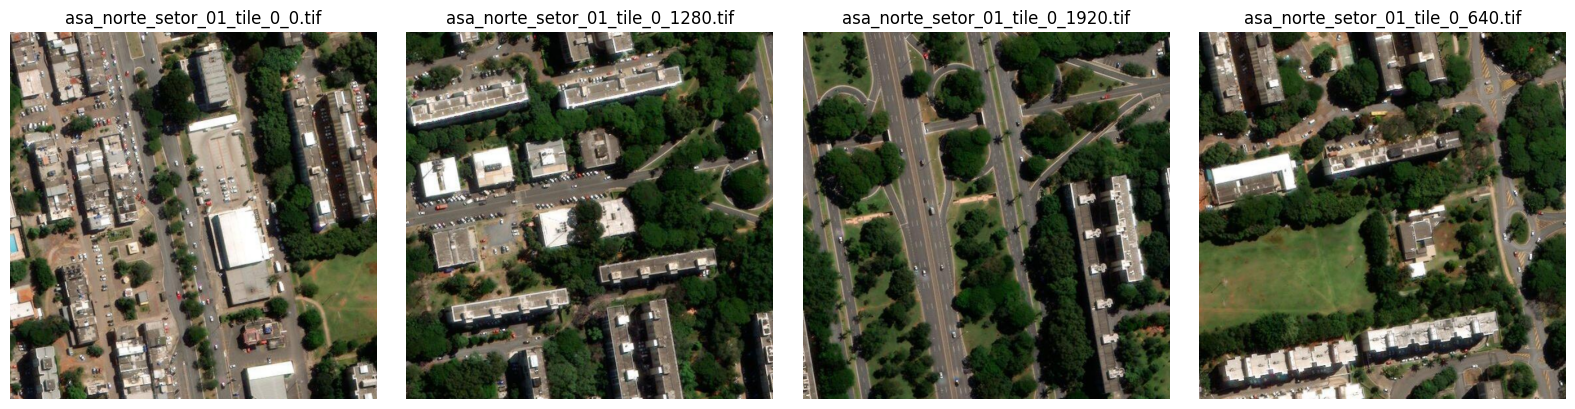

In [8]:
total_tiles = 0
all_dimensions_ok = True
all_georeferencing_ok = True

for geotiff_path in input_geotiffs:
    output_tile_dir = TILES_DIR / geotiff_path.stem
    sector_tiles = count_tiles(output_tile_dir)
    total_tiles += sector_tiles

    print(f"\nValidando {geotiff_path.stem}: {sector_tiles} tiles")
    all_dimensions_ok = validate_tile_dimensions(output_tile_dir, expected_size=640) and all_dimensions_ok
    all_georeferencing_ok = validate_tile_georeferencing(output_tile_dir) and all_georeferencing_ok

print(f"\nTotal de GeoTIFFs validados: {len(input_geotiffs)}")
print(f"Total de tiles encontrados: {total_tiles}")
print(f"Dimensoes validas em todos os setores: {all_dimensions_ok}")
print(f"Georreferenciamento valido em todos os setores: {all_georeferencing_ok}")

if input_geotiffs:
    show_sample_tiles(TILES_DIR / input_geotiffs[0].stem, n=4)

## Criando arquivo para mapeamento dos tiles

In [9]:
mapping_rows = []

tile_counter = 0

for sector_name, tile_paths in generated_tiles_by_sector.items():

    # Garante a mesma ordem utilizada no restante do notebook
    tile_paths = sorted(tile_paths)

    for tile_path in tile_paths:

        mapping_rows.append(
            {
                "tile_hdf5": f"tile_{tile_counter}",
                "sector": sector_name,
                "tile_filename": Path(tile_path).name,
            }
        )

        tile_counter += 1

mapping_df = pd.DataFrame(mapping_rows)

mapping_df.head()

,tile_hdf5,sector,tile_filename
0,tile_0,asa_norte_setor_01,asa_norte_setor_01_tile_0_0.tif
1,tile_1,asa_norte_setor_01,asa_norte_setor_01_tile_0_1280.tif
2,tile_2,asa_norte_setor_01,asa_norte_setor_01_tile_0_1920.tif
3,tile_3,asa_norte_setor_01,asa_norte_setor_01_tile_0_640.tif
4,tile_4,asa_norte_setor_01,asa_norte_setor_01_tile_1280_0.tif


## Salvando o CSV

In [10]:
OUTPUT_MAPPING = TILES_DIR.parent / "tile_mapping.csv"

mapping_df.to_csv(
    OUTPUT_MAPPING,
    index=False
)

print(f"Arquivo salvo em:\n{OUTPUT_MAPPING}")

print()

print(mapping_df.head())

print()

print(f"{len(mapping_df)} registros criados.")

Arquivo salvo em:
/home/kohara/IIA/IIA-Arvores-AsaNorte/data/tile_mapping.csv

  tile_hdf5              sector                       tile_filename
0    tile_0  asa_norte_setor_01     asa_norte_setor_01_tile_0_0.tif
1    tile_1  asa_norte_setor_01  asa_norte_setor_01_tile_0_1280.tif
2    tile_2  asa_norte_setor_01  asa_norte_setor_01_tile_0_1920.tif
3    tile_3  asa_norte_setor_01   asa_norte_setor_01_tile_0_640.tif
4    tile_4  asa_norte_setor_01  asa_norte_setor_01_tile_1280_0.tif

96 registros criados.
